## Chronic pain related fMRI data
#### home assignment programming for psychologists 
Lorna Schlüter - completed on 6th December 2025
Data: https://neurosynth.org/analyses/terms/chronic%20pain/

Step 1 - Locating MRI data automatically.

In [ ]:
import glob
import os 

# the source folder path
#os.chdir("/Users/lornaschluter/Desktop") # to get to folder above current wd (function won't find the source folder if we're already in it!)
print(os.getcwd()) # check current wd
source = "home_assignment_programming"

# find all files with file extension .nii
file_ex = "*.nii"
find_files = os.path.join(source, file_ex)
ddmri = glob.glob(find_files)
print(ddmri)


/Users/lornaschluter/Desktop
home_assignment_programming/*.nii
['home_assignment_programming/chronic pain_uniformity-test_z_FDR_0.01.nii', 'home_assignment_programming/anatomical.nii']


Step 2 - Visualizing functional MRI data related to chronic pain on top of anatomical MRI scan using nilearn's plotting function. 

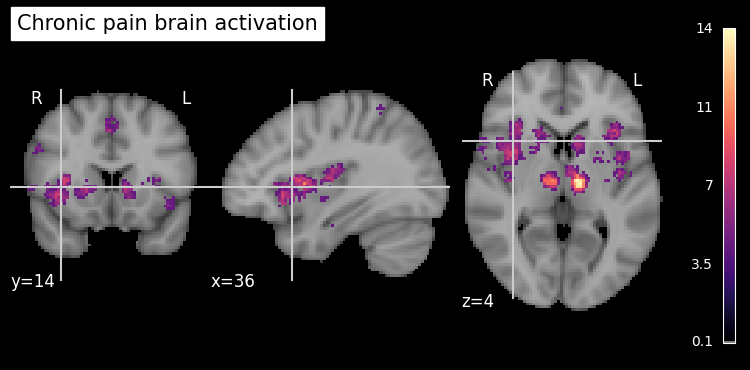

In [ ]:
import nilearn
from nilearn import plotting

# variables w img data
stat_map_img = "home_assignment_programming/chronic pain_uniformity-test_z_FDR_0.01.nii"
bg_img = "home_assignment_programming/anatomical.nii"

# plotting with specific cut coordinates, title, threshold and colour map
nilearn.plotting.plot_stat_map(
    stat_map_img,
    bg_img,
    cut_coords=(36, 14, 4),
    title="Chronic pain brain activation",
    threshold=0.1,
    cmap="viridis",
    radiological=True
)

Step 3 - Plotting a histogram showing the distribution of voxel intensity of the chronic pain related fMRI data using only positive values. 

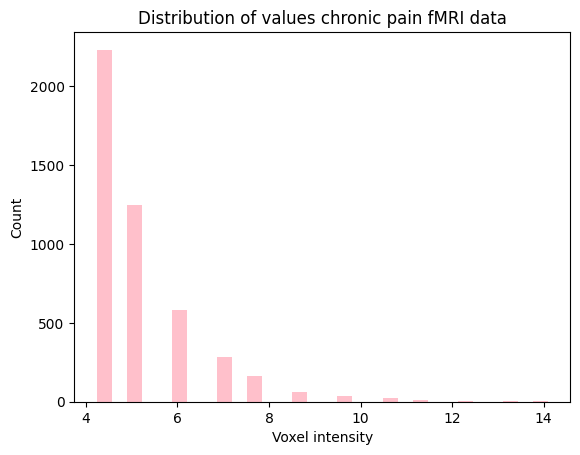

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt

f_img = nib.load(stat_map_img)  # loading data, but only getting metadata
img_data = (
    f_img.get_fdata()
)  # getting actual voxel data we're interested in as a numpy array

positive_vals = img_data > 0  # filtering for positive values only
histo_data = img_data[positive_vals]  # creating new array with positive values only

# plot histogram and add axes labels, title and custom color
plt.hist(histo_data, bins=30, color="green")
plt.xlabel("Voxel intensity")
plt.ylabel("Count")
plt.title("Distribution of values chronic pain fMRI data")
plt.show()